In [55]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

from numba import cuda

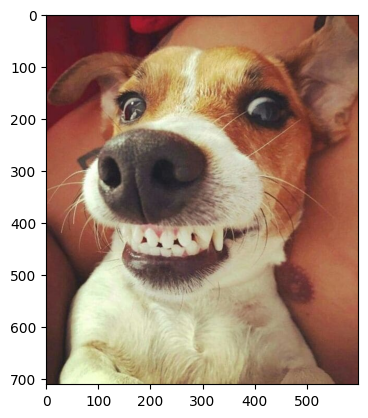

In [56]:
img = plt.imread("/content/dog.jpg")

plt.imshow(img)

In [57]:
height, width, channels = img.shape
pixelCount = height*width

flatSrc = img.reshape(pixelCount, 3)

In [81]:
start = time.time()
gray_cpu = np.zeros(pixelCount, dtype=np.uint8)

for i in range(pixelCount):

    r = flatSrc[i, 0]
    g = flatSrc[i, 1]
    b = flatSrc[i, 2]

    gray_cpu[i] = (int(r)+int(g)+int(b))//3

end = time.time()
cpu_time = end - start
print(f"CPU time: {cpu_time:.6f}, seconds")

CPU time: 0.454782, seconds


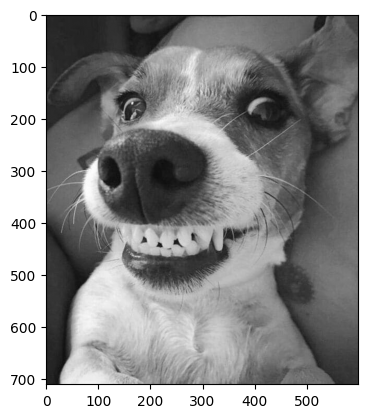

In [59]:
gc_image = gray_cpu.reshape(height, width)

plt.imshow(gc_image, cmap="gray")
plt.imsave("/content/gc.png", gc_image, cmap="gray")

1D GPU

In [60]:
devSrc1D = cuda.to_device(flatSrc)
devDst1D = cuda.device_array((pixelCount, 3), dtype=np.uint8)

In [61]:
blockSize1D = 64
gridSize1D = math.ceil(pixelCount/blockSize1D)

In [62]:
@cuda.jit
def grayscale_1D(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

In [82]:
block_sizes = [32, 64, 128, 256, 512, 1024]
gpu_times = []

for blockSize in block_sizes:
    gridSize = (pixelCount+blockSize-1) // blockSize
    devDst = cuda.device_array((pixelCount, 3), dtype=np.uint8)

    start = time.time()

    grayscale_1D[gridSize, blockSize](devSrc1D, devDst1D)
    cuda.synchronize()

    end = time.time()

    gpu_time = end - start
    gpu_times.append(gpu_time)

    print(f"Block size: {blockSize}")
    print(f"Grid size: {gridSize}")
    print(f"GPU time: {gpu_time:.6f} seconds")
    print()

Block size: 32
Grid size: 13313
GPU time: 0.000422 seconds

Block size: 64
Grid size: 6657
GPU time: 0.000250 seconds

Block size: 128
Grid size: 3329
GPU time: 0.000535 seconds

Block size: 256
Grid size: 1665
GPU time: 0.000389 seconds

Block size: 512
Grid size: 833
GPU time: 0.000227 seconds

Block size: 1024
Grid size: 417
GPU time: 0.000217 seconds



2D GPU

In [84]:
devSrc = cuda.to_device(img)
devDst = cuda.device_array(img.shape, dtype=np.uint8)

In [83]:
gridSize = (8, 8)
blockSize = (32, 32)

In [85]:
@cuda.jit
def grayscale(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  g = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)
  dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = g

In [88]:
start = time.time()

grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()
end = time.time()

gpu_time_2D = end - start
print(f"GPU time: {gpu_time_2D} seconds")

GPU time: 0.0009641647338867188 seconds


In [89]:
gray_gpu = devDst.copy_to_host()

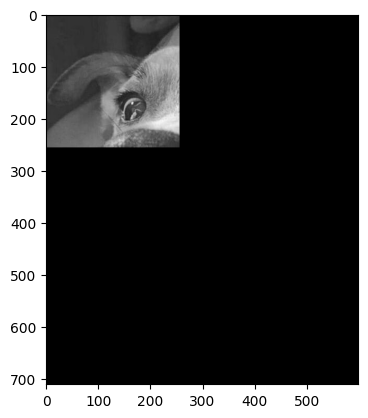

In [90]:
gp_image = gray_gpu.reshape(height, width, 3)

plt.imshow(gp_image, cmap="gray")
plt.imsave("/content/gp.png", gp_image, cmap="gray")

In [94]:
speedup_2d = cpu_time / gpu_time_2D

print(f"CPU time: {cpu_time:.6f} seconds")
print(f"2D GPU time: {gpu_time_2D:.6f} seconds")
print(f"2D speedup: {speedup_2d:.2f}x")

CPU time: 0.454782 seconds
2D GPU time: 0.000964 seconds
2D speedup: 471.69x


In [105]:
block_2d = [(8,4), (16,4), (8,16), (16,16), (32,16), (32,32)]
gpu_times_2d = []
gridSizes_2d = []
speedups_2d = []

for block in block_2d:
    block_x = block[0]
    block_y = block[1]
    blockSize_2D = (block_x, block_y)
    gridSize_2D = (math.ceil(width/block_x), math.ceil(height/block_y))

    start = time.time()
    grayscale[gridSize_2D, blockSize_2D](devSrc, devDst)

    cuda.synchronize()
    end = time.time()
    gpu_time = end - start
    speedup = cpu_time / gpu_time

    gpu_times_2d.append(gpu_time)
    speedups_2d.append(speedup)
    gridSizes_2d.append(gridSize_2D)

    print(f"Block size: {block_x} x {block_y}")
    print(f"Grid size: {gridSize_2D}")
    print(f"Threads per block: {block_x * block_y}")
    print(f"GPU time: {gpu_time:.6f} seconds")
    print(f"Speedup: {speedup:.2f}x")
    print()

Block size: 8 x 4
Grid size: (75, 178)
Threads per block: 32
GPU time: 0.001798 seconds
Speedup: 252.98x

Block size: 16 x 4
Grid size: (38, 178)
Threads per block: 64
GPU time: 0.000271 seconds
Speedup: 1680.61x

Block size: 8 x 16
Grid size: (75, 45)
Threads per block: 128
GPU time: 0.000229 seconds
Speedup: 1986.97x

Block size: 16 x 16
Grid size: (38, 45)
Threads per block: 256
GPU time: 0.000236 seconds
Speedup: 1924.82x

Block size: 32 x 16
Grid size: (19, 45)
Threads per block: 512
GPU time: 0.000232 seconds
Speedup: 1958.41x

Block size: 32 x 32
Grid size: (19, 23)
Threads per block: 1024
GPU time: 0.000241 seconds
Speedup: 1886.74x



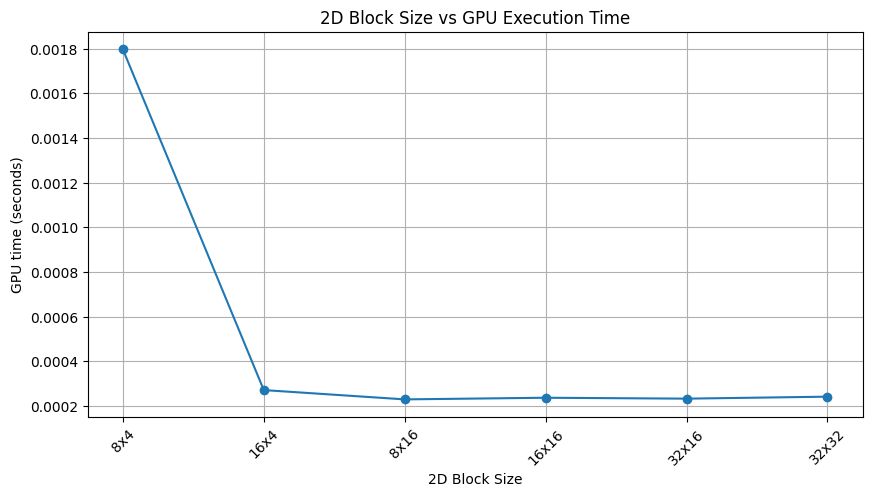

In [106]:
block_labels = [f"{x}x{y}" for x, y in block_2d]

plt.figure(figsize=(10, 5))
plt.plot(block_labels, gpu_times_2d, marker="o")
plt.xlabel("2D Block Size")
plt.ylabel("GPU time (seconds)")
plt.title("2D Block Size vs GPU Execution Time")

plt.xticks(rotation=45)
plt.grid(True)

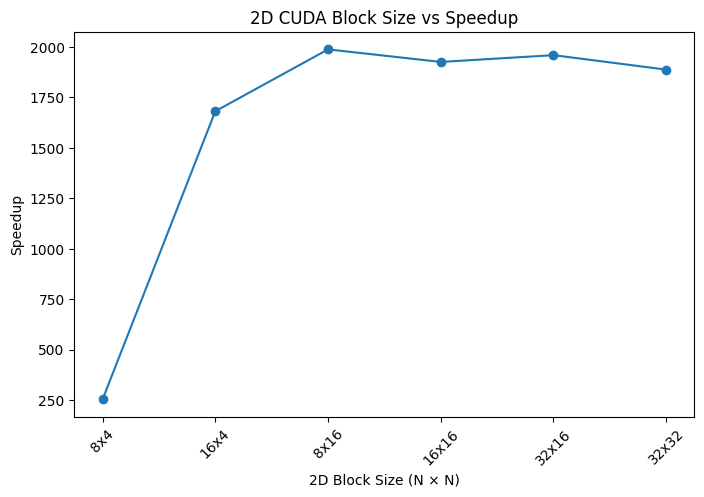

In [110]:
block_labels = [f"{x}x{y}" for x, y in block_2d]
plt.figure(figsize=(8, 5))
plt.plot(block_labels, speedups_2d, marker="o")

plt.xlabel("2D Block Size")
plt.ylabel("Speedup")
plt.title("2D CUDA Block Size vs Speedup")
plt.xticks(rotation=45)
plt.show()